# 12/345, confi 1 = 4 Binary Classifier - 1-layer MLP

This Colab notebook uses the same input features and 1-layer MLP structure as the provided confidence-4 upsampling notebook.

Binary labels:
- 0: confidence 1, 2
- 1: confidence 3, 4, 5

The original 1-5 confidence distribution is shown first. Train/validation/test are stratified by original confidence 1-5, then only the train split adjusts confidence 1 to match the confidence 4 train count by random sampling. Duplicated confidence-1 rows receive Gaussian noise on CLAP embedding dimensions.


In [1]:
# =====================================================
# 1. IMPORTS AND REPRODUCIBILITY
# =====================================================
import os
import random
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from IPython.display import display, Image
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    IN_COLAB = False

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)


DEVICE: cuda


In [2]:
# =====================================================
# 2. GOOGLE DRIVE MOUNT
# =====================================================
if IN_COLAB:
    drive.mount("/content/drive")

# =====================================================
# 3. PATH SETTINGS
# =====================================================
# Drive original paths
METADATA_CSV = "/content/drive/MyDrive/DCASE2026/data/metadata/BSD10k_metadata.csv"

DRIVE_AUDIO_EMB_DIR = "/content/drive/MyDrive/DCASE2026/data/features/clap_audio_embeddings"
DRIVE_TEXT_EMB_DIR  = "/content/drive/MyDrive/DCASE2026/data/features/clap_text_embeddings"

# Colab local paths
LOCAL_BASE_DIR = "/content/bsd10k_features"

AUDIO_EMB_DIR = os.path.join(
    LOCAL_BASE_DIR,
    "clap_audio_embeddings"
)

TEXT_EMB_DIR = os.path.join(
    LOCAL_BASE_DIR,
    "clap_text_embeddings"
)

# Column names
SOUND_ID_COL = "sound_id"
CLASS_COL = "class"
CONFIDENCE_COL = "confidence"

OUTPUT_BASE_DIR = "/content/drive/MyDrive/DCASE2026/outputs/up_sampling_confi4_binary"

print("METADATA_CSV:", METADATA_CSV)
print("DRIVE_AUDIO_EMB_DIR:", DRIVE_AUDIO_EMB_DIR)
print("DRIVE_TEXT_EMB_DIR:", DRIVE_TEXT_EMB_DIR)
print("AUDIO_EMB_DIR:", AUDIO_EMB_DIR)
print("TEXT_EMB_DIR:", TEXT_EMB_DIR)
print("OUTPUT_BASE_DIR:", OUTPUT_BASE_DIR)


Mounted at /content/drive
METADATA_CSV: /content/drive/MyDrive/DCASE2026/data/metadata/BSD10k_metadata.csv
DRIVE_AUDIO_EMB_DIR: /content/drive/MyDrive/DCASE2026/data/features/clap_audio_embeddings
DRIVE_TEXT_EMB_DIR: /content/drive/MyDrive/DCASE2026/data/features/clap_text_embeddings
AUDIO_EMB_DIR: /content/bsd10k_features/clap_audio_embeddings
TEXT_EMB_DIR: /content/bsd10k_features/clap_text_embeddings
OUTPUT_BASE_DIR: /content/drive/MyDrive/DCASE2026/outputs/up_sampling_confi4_binary


In [3]:
# =====================================================
# 4. EXPERIMENT SETTINGS
# =====================================================
TEST_SIZE = 0.20
VALID_SIZE = 0.20
BATCH_SIZE = 256
NUM_EPOCHS = 120
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE = 15

# Noise is applied only to duplicated upsampled embedding values, not to original rows.
NOISE_STD = 0.01

# Only confidence 1 is sampled until it reaches the confidence 4 train count.
# If confidence 1 is already above confidence 4, this keeps original confidence 1 rows.
DOWNSAMPLE_CONFIDENCE1_IF_ABOVE_CONFIDENCE4 = False

USE_AUDIO_EMB = True
USE_TEXT_EMB = True
USE_CLASS_ONEHOT = True
USE_DESCRIPTION_LENGTH = False

ORIGINAL_LABELS = [1, 2, 3, 4, 5]
BINARY_LABELS = [0, 1]


In [4]:
# =====================================================
# BINARY LABEL SETTINGS
# =====================================================
EXPERIMENT_NAME = "12_345_confi1_eq_4_1layer_mlp_binary_classifier"
NEGATIVE_CONFIDENCES = [1, 2]
POSITIVE_CONFIDENCES = [3, 4, 5]
BINARY_LABEL_NAMES = {
    0: "confidence12",
    1: "confidence345",
}

print("Binary task:", BINARY_LABEL_NAMES[0], "vs", BINARY_LABEL_NAMES[1])
print("0:", NEGATIVE_CONFIDENCES)
print("1:", POSITIVE_CONFIDENCES)


Binary task: confidence12 vs confidence345
0: [1, 2]
1: [3, 4, 5]


In [5]:
# =====================================================
# 5. DATA LOADING, SPLIT, AND CONFIDENCE-1 SAMPLING
# =====================================================
def copy_drive_features_to_local():
    # Copy Drive embeddings to Colab local disk for faster np.load calls.
    Path(LOCAL_BASE_DIR).mkdir(parents=True, exist_ok=True)
    for src, dst in [
        (DRIVE_AUDIO_EMB_DIR, AUDIO_EMB_DIR),
        (DRIVE_TEXT_EMB_DIR, TEXT_EMB_DIR),
    ]:
        src_path = Path(src)
        dst_path = Path(dst)
        if dst_path.exists() and any(dst_path.iterdir()):
            print(f"Already exists: {dst_path}")
            continue
        print(f"Copying {src_path} -> {dst_path}")
        shutil.copytree(src_path, dst_path, dirs_exist_ok=True)


def finite_float32(x):
    return np.nan_to_num(
        np.asarray(x, dtype=np.float32),
        nan=0.0,
        posinf=0.0,
        neginf=0.0,
    ).astype(np.float32)


def clean_metadata(df):
    df = df.copy()
    df[SOUND_ID_COL] = df[SOUND_ID_COL].astype(str).str.strip()
    df[CLASS_COL] = df[CLASS_COL].astype(str).str.strip()
    df[CONFIDENCE_COL] = pd.to_numeric(df[CONFIDENCE_COL], errors="coerce")
    df = df[df[CONFIDENCE_COL].isin(ORIGINAL_LABELS)].copy()
    df[CONFIDENCE_COL] = df[CONFIDENCE_COL].astype(int)

    # Follow the existing repository convention: remove class_idx values ending in 99 or 00 when present.
    if "class_idx" in df.columns:
        class_idx = df["class_idx"].astype(str).str.strip()
        keep = ~((class_idx.str.len() == 3) & (class_idx.str.endswith("99") | class_idx.str.endswith("00")))
        df = df[keep].copy()

    return df.reset_index(drop=True)


def one_hot(values, categories):
    category_to_idx = {category: idx for idx, category in enumerate(categories)}
    arr = np.zeros((len(values), len(categories)), dtype=np.float32)
    for row_idx, value in enumerate(values):
        arr[row_idx, category_to_idx[str(value)]] = 1.0
    return arr


def load_embedding(path):
    return finite_float32(np.load(path).reshape(-1))


def build_dataset():
    copy_drive_features_to_local()

    meta = clean_metadata(pd.read_csv(METADATA_CSV))
    audio_dir = Path(AUDIO_EMB_DIR)
    text_dir = Path(TEXT_EMB_DIR)

    kept_rows = []
    audio_rows = []
    text_rows = []

    for _, row in meta.iterrows():
        sound_id = str(row[SOUND_ID_COL])
        audio_path = audio_dir / f"{sound_id}.npy"
        text_path = text_dir / f"{sound_id}.npy"
        if audio_path.is_file() and text_path.is_file():
            kept_rows.append(row)
            audio_rows.append(load_embedding(audio_path))
            text_rows.append(load_embedding(text_path))

    df = pd.DataFrame(kept_rows).reset_index(drop=True)
    audio = finite_float32(np.vstack(audio_rows))
    text = finite_float32(np.vstack(text_rows))

    categories = sorted(df[CLASS_COL].astype(str).unique().tolist())
    feature_parts = []
    noise_slices = []
    start = 0

    if USE_AUDIO_EMB:
        feature_parts.append(audio)
        noise_slices.append(slice(start, start + audio.shape[1]))
        start += audio.shape[1]
        print("audio:", audio.shape)

    if USE_TEXT_EMB:
        feature_parts.append(text)
        noise_slices.append(slice(start, start + text.shape[1]))
        start += text.shape[1]
        print("text:", text.shape)

    if USE_CLASS_ONEHOT:
        class_oh = one_hot(df[CLASS_COL].astype(str).tolist(), categories)
        feature_parts.append(class_oh)
        start += class_oh.shape[1]
        print("class_onehot:", class_oh.shape)

    if USE_DESCRIPTION_LENGTH:
        desc = df["description"] if "description" in df.columns else pd.Series([""] * len(df))
        desc_len = desc.fillna("").astype(str).str.len().to_numpy(dtype=np.float32).reshape(-1, 1)
        feature_parts.append(desc_len)
        start += 1
        print("description_length:", desc_len.shape)

    X = finite_float32(np.concatenate(feature_parts, axis=1))
    y_conf = df[CONFIDENCE_COL].to_numpy(dtype=np.int64)

    noise_mask = np.zeros(X.shape[1], dtype=bool)
    for s in noise_slices:
        noise_mask[s] = True

    print("samples:", len(df), "features:", X.shape[1])
    print("\nOriginal confidence distribution")
    display(pd.Series(y_conf).value_counts().reindex(ORIGINAL_LABELS, fill_value=0).rename("full_data_confidence_count"))
    return df, X, y_conf, noise_mask, categories


def make_splits(y_conf):
    # Stratify by the original 1-5 confidence values so all splits keep the same confidence ratio.
    idx = np.arange(len(y_conf))
    train_idx, temp_idx = train_test_split(
        idx,
        test_size=TEST_SIZE + VALID_SIZE,
        random_state=SEED,
        stratify=y_conf,
    )
    relative_test_size = TEST_SIZE / (TEST_SIZE + VALID_SIZE)
    valid_idx, test_idx = train_test_split(
        temp_idx,
        test_size=relative_test_size,
        random_state=SEED,
        stratify=y_conf[temp_idx],
    )
    return train_idx, valid_idx, test_idx


def to_binary_labels(y_conf):
    y_bin = np.isin(y_conf, POSITIVE_CONFIDENCES).astype(np.int64)
    return y_bin


def confidence_distribution_table(y_conf, split_name):
    return pd.Series(y_conf).value_counts().reindex(ORIGINAL_LABELS, fill_value=0).astype(int).rename(split_name)


def binary_distribution_table(y_bin, split_name):
    return pd.Series(y_bin).value_counts().reindex(BINARY_LABELS, fill_value=0).astype(int).rename(split_name)


def sample_confidence1_to_confidence4(X_train, y_train_conf, noise_mask):
    rng = np.random.default_rng(SEED)
    before = pd.Series(y_train_conf).value_counts().reindex(ORIGINAL_LABELS, fill_value=0).astype(int)
    conf1_n = int(before.loc[1])
    conf4_n = int(before.loc[4])
    if conf1_n <= 0:
        raise ValueError("confidence 1 count is zero in the train split.")
    if conf4_n <= 0:
        raise ValueError("confidence 4 count is zero in the train split.")

    keep_pos = np.arange(len(y_train_conf))
    x_parts = [X_train[keep_pos].copy()]
    y_conf_parts = [y_train_conf[keep_pos].copy()]
    aug_flags = [False] * len(keep_pos)

    conf1_pos = np.flatnonzero(y_train_conf == 1)
    duplicate_pos = np.array([], dtype=np.int64)
    removed_original_pos = np.array([], dtype=np.int64)

    if conf1_n < conf4_n:
        duplicate_pos = rng.choice(conf1_pos, size=conf4_n - conf1_n, replace=True)
        x_dup = X_train[duplicate_pos].copy()
        noise = rng.normal(loc=0.0, scale=NOISE_STD, size=x_dup[:, noise_mask].shape).astype(np.float32)
        x_dup[:, noise_mask] = x_dup[:, noise_mask] + noise
        x_parts.append(x_dup)
        y_conf_parts.append(y_train_conf[duplicate_pos].copy())
        aug_flags.extend([True] * len(x_dup))
        action = "confidence1_upsample_with_noise_to_confidence4_count"
    elif conf1_n > conf4_n and DOWNSAMPLE_CONFIDENCE1_IF_ABOVE_CONFIDENCE4:
        chosen_conf1 = rng.choice(conf1_pos, size=conf4_n, replace=False)
        keep_mask = np.ones(len(y_train_conf), dtype=bool)
        drop_conf1 = np.setdiff1d(conf1_pos, chosen_conf1, assume_unique=False)
        keep_mask[drop_conf1] = False
        x_parts = [X_train[keep_mask].copy()]
        y_conf_parts = [y_train_conf[keep_mask].copy()]
        aug_flags = [False] * int(keep_mask.sum())
        removed_original_pos = drop_conf1
        action = "confidence1_downsample_to_confidence4_count"
    elif conf1_n > conf4_n:
        action = "confidence1_kept_original_above_confidence4_count"
    else:
        action = "confidence1_already_equal_confidence4_count"

    X_sampled = finite_float32(np.vstack(x_parts))
    y_conf_sampled = np.concatenate(y_conf_parts).astype(np.int64)
    aug_flags = np.asarray(aug_flags, dtype=bool)

    order = rng.permutation(len(y_conf_sampled))
    X_sampled = X_sampled[order]
    y_conf_sampled = y_conf_sampled[order]
    aug_flags = aug_flags[order]

    after = pd.Series(y_conf_sampled).value_counts().reindex(ORIGINAL_LABELS, fill_value=0).astype(int)
    plan = pd.DataFrame([{
        "class_adjusted": "confidence_1",
        "confidence1_before": conf1_n,
        "confidence4_train_target": conf4_n,
        "added_noisy_confidence1_duplicates": int(len(duplicate_pos)),
        "removed_confidence1_originals": int(len(removed_original_pos)),
        "confidence1_after": int(after.loc[1]),
        "confidence4_after": int(after.loc[4]),
        "action": action,
    }])
    return X_sampled, y_conf_sampled, aug_flags, plan


def make_loader(X_np, y_np, batch_size=BATCH_SIZE, shuffle=False):
    x_tensor = torch.from_numpy(finite_float32(X_np))
    y_tensor = torch.from_numpy(y_np.astype(np.int64))
    dataset = TensorDataset(x_tensor, y_tensor)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, num_workers=0, pin_memory=torch.cuda.is_available())


def classification_metrics(y_true, y_pred_class, mae_score=None):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred_class,
        labels=BINARY_LABELS,
        average="macro",
        zero_division=0,
    )
    mae_source = y_pred_class if mae_score is None else mae_score
    return {
        "accuracy": float(accuracy_score(y_true, y_pred_class)),
        "macro_precision": float(precision),
        "macro_recall": float(recall),
        "macro_f1": float(f1),
        "mae": float(mean_absolute_error(y_true, mae_source)),
    }


def save_loss_curve(history, title, out_path):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(history["epoch"], history["train_loss"], label="train loss")
    ax.plot(history["epoch"], history["val_loss"], label="validation loss")
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()
    fig.savefig(out_path, dpi=160)
    plt.show()


def save_confusion(y_true, y_pred, title, out_path):
    cm = confusion_matrix(y_true, y_pred, labels=BINARY_LABELS)
    cm_norm = cm.astype(np.float32) / np.maximum(cm.sum(axis=1, keepdims=True), 1)

    fig, ax = plt.subplots(figsize=(5.6, 4.8))
    im = ax.imshow(cm_norm, vmin=0.0, vmax=1.0, cmap="Blues")
    ax.set_title(title)
    ax.set_xlabel("Predicted binary label")
    ax.set_ylabel("True binary label")
    ax.set_xticks(range(len(BINARY_LABELS)), [BINARY_LABEL_NAMES[i] for i in BINARY_LABELS])
    ax.set_yticks(range(len(BINARY_LABELS)), [BINARY_LABEL_NAMES[i] for i in BINARY_LABELS])
    for i in range(len(BINARY_LABELS)):
        for j in range(len(BINARY_LABELS)):
            ax.text(j, i, f"{cm_norm[i, j] * 100:.1f}%", ha="center", va="center", fontsize=9)
    fig.colorbar(im, ax=ax)
    fig.tight_layout()
    fig.savefig(out_path, dpi=160)
    plt.show()
    return cm, cm_norm


In [6]:
# =====================================================
# 6. SPLIT FIRST, THEN TRAIN-ONLY CONFIDENCE-1 SAMPLING
# =====================================================
df, X, y_conf, noise_mask, class_categories = build_dataset()
train_idx, valid_idx, test_idx = make_splits(y_conf)

X_train_raw = X[train_idx]
y_train_conf_raw = y_conf[train_idx]
X_valid_raw = X[valid_idx]
y_valid_conf = y_conf[valid_idx]
X_test_raw = X[test_idx]
y_test_conf = y_conf[test_idx]

X_train_sampled_raw, y_train_conf_sampled, is_noisy_duplicate, resample_plan = sample_confidence1_to_confidence4(
    X_train_raw,
    y_train_conf_raw,
    noise_mask,
)

y_train = to_binary_labels(y_train_conf_sampled)
y_valid = to_binary_labels(y_valid_conf)
y_test = to_binary_labels(y_test_conf)

# Fit scaler on the original train split, then transform sampled train/valid/test.
scaler = StandardScaler()
scaler.fit(X_train_raw)
X_train = scaler.transform(X_train_sampled_raw).astype(np.float32)
X_valid = scaler.transform(X_valid_raw).astype(np.float32)
X_test = scaler.transform(X_test_raw).astype(np.float32)

print("split sizes before confidence-1 sampling:", len(train_idx), len(valid_idx), len(test_idx))
print("train after confidence-1 sampling:", len(X_train))
print("noisy duplicated confidence-1 train rows:", int(is_noisy_duplicate.sum()))

print("\nOriginal confidence distribution by split")
split_conf_counts = pd.concat([
    confidence_distribution_table(y_conf, "full"),
    confidence_distribution_table(y_train_conf_raw, "train_before_sampling"),
    confidence_distribution_table(y_valid_conf, "validation"),
    confidence_distribution_table(y_test_conf, "test"),
], axis=1)
display(split_conf_counts)
print("These are the approximately fair stratified split counts for confidence 1, 2, 3, 4, 5.")

print("\nConfidence-1 to confidence-4 sampling plan")
display(resample_plan)

print("\nTrain confidence distribution after confidence-1 sampling")
display(confidence_distribution_table(y_train_conf_sampled, "train_after_sampling"))

print("\nBinary distribution")
binary_counts = pd.concat([
    binary_distribution_table(to_binary_labels(y_train_conf_raw), "train_before_sampling"),
    binary_distribution_table(y_train, "train_after_sampling"),
    binary_distribution_table(y_valid, "validation"),
    binary_distribution_table(y_test, "test"),
], axis=1)
binary_counts.index = [BINARY_LABEL_NAMES[i] for i in binary_counts.index]
display(binary_counts)


Copying /content/drive/MyDrive/DCASE2026/data/features/clap_audio_embeddings -> /content/bsd10k_features/clap_audio_embeddings
Copying /content/drive/MyDrive/DCASE2026/data/features/clap_text_embeddings -> /content/bsd10k_features/clap_text_embeddings
audio: (10956, 512)
text: (10956, 512)
class_onehot: (10956, 23)
samples: 10956 features: 1047

Original confidence distribution


,full_data_confidence_count
1,107
2,748
3,3281
4,6043
5,777


split sizes before confidence-1 sampling: 6573 2191 2192
train after confidence-1 sampling: 10135
noisy duplicated confidence-1 train rows: 3562

Original confidence distribution by split


,full,train_before_sampling,validation,test
1,107,64,22,21
2,748,449,150,149
3,3281,1968,656,657
4,6043,3626,1208,1209
5,777,466,155,156


These are the approximately fair stratified split counts for confidence 1, 2, 3, 4, 5.

Confidence-1 to confidence-4 sampling plan


,class_adjusted,confidence1_before,confidence4_train_target,added_noisy_confidence1_duplicates,removed_confidence1_originals,confidence1_after,confidence4_after,action
0,confidence_1,64,3626,3562,0,3626,3626,confidence1_upsample_with_noise_to_confidence4...



Train confidence distribution after confidence-1 sampling


,train_after_sampling
1,3626
2,449
3,1968
4,3626
5,466



Binary distribution


,train_before_sampling,train_after_sampling,validation,test
confidence12,513,4075,172,170
confidence345,6060,6060,2019,2022


[001/120] train_loss=0.6224 val_loss=0.7358 val_f1=0.4494 val_mae=0.4331
[010/120] train_loss=0.4358 val_loss=0.5269 val_f1=0.5473 val_mae=0.2478
[020/120] train_loss=0.3856 val_loss=0.4303 val_f1=0.5638 val_mae=0.1894
[030/120] train_loss=0.3606 val_loss=0.3936 val_f1=0.5769 val_mae=0.1666
[040/120] train_loss=0.3521 val_loss=0.3771 val_f1=0.5778 val_mae=0.1565
[050/120] train_loss=0.3493 val_loss=0.3803 val_f1=0.5805 val_mae=0.1607
[060/120] train_loss=0.3464 val_loss=0.3624 val_f1=0.5818 val_mae=0.1483
[070/120] train_loss=0.3426 val_loss=0.3622 val_f1=0.5767 val_mae=0.1502
[080/120] train_loss=0.3494 val_loss=0.3721 val_f1=0.5781 val_mae=0.1524
Early stopping at epoch 87


,split,accuracy,macro_precision,macro_recall,macro_f1,mae
0,validation,0.858969,0.572814,0.596379,0.581525,0.141031
1,test,0.852646,0.560525,0.583392,0.568289,0.147354


Validation classification report
               precision    recall  f1-score   support

 confidence12       0.21      0.28      0.24       172
confidence345       0.94      0.91      0.92      2019

     accuracy                           0.86      2191
    macro avg       0.57      0.60      0.58      2191
 weighted avg       0.88      0.86      0.87      2191

Test classification report
               precision    recall  f1-score   support

 confidence12       0.19      0.26      0.22       170
confidence345       0.94      0.90      0.92      2022

     accuracy                           0.85      2192
    macro avg       0.56      0.58      0.57      2192
 weighted avg       0.88      0.85      0.86      2192

Validation classification report dataframe


,precision,recall,f1-score,support
confidence12,0.208511,0.284884,0.240786,172.000000
confidence345,0.937117,0.907875,0.922264,2019.000000
accuracy,0.858969,0.858969,0.858969,0.858969
macro avg,0.572814,0.596379,0.581525,2191.000000
weighted avg,0.879919,0.858969,0.868766,2191.000000


Test classification report dataframe


,precision,recall,f1-score,support
confidence12,0.185185,0.264706,0.217918,170.000000
confidence345,0.935865,0.902077,0.918660,2022.000000
accuracy,0.852646,0.852646,0.852646,0.852646
macro avg,0.560525,0.583392,0.568289,2192.000000
weighted avg,0.877646,0.852646,0.864314,2192.000000


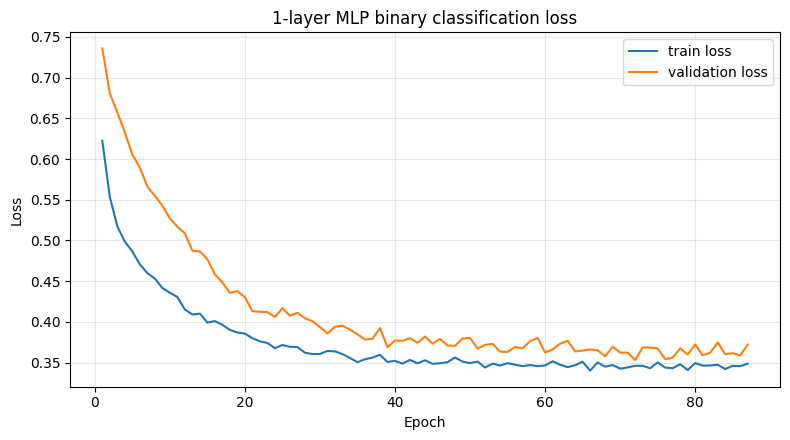

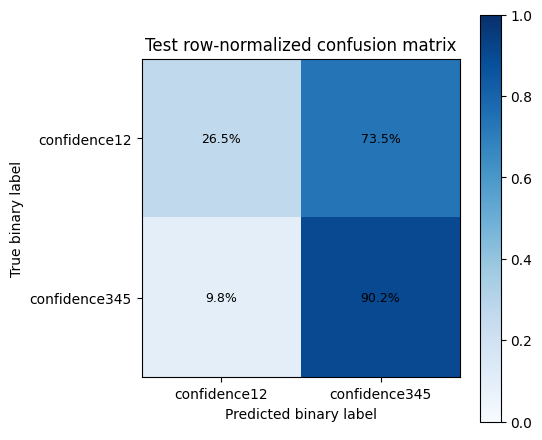

Saved to: /content/drive/MyDrive/DCASE2026/outputs/up_sampling_confi4_binary/12_345_confi1_eq_4_1layer_mlp_binary_classifier


In [7]:
# =====================================================
# 7. 1-LAYER MLP BINARY CLASSIFICATION
# =====================================================
OUTPUT_DIR = Path(OUTPUT_BASE_DIR) / EXPERIMENT_NAME
REPORT_DIR = OUTPUT_DIR / "reports"
PLOT_DIR = OUTPUT_DIR / "plots"
PRED_DIR = OUTPUT_DIR / "predictions"
for path in [REPORT_DIR, PLOT_DIR, PRED_DIR]:
    path.mkdir(parents=True, exist_ok=True)

resample_plan.to_csv(REPORT_DIR / "confidence1_to_confidence4_sampling_plan.csv", index=False)

class OneLayerMLPBinaryClassifier(nn.Module):
    def __init__(self, input_dim, num_classes=2, dropout=0.4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(input_dim, num_classes),
        )

    def forward(self, x):
        return self.net(x)


@torch.no_grad()
def predict_classifier(model, X_np, y_np):
    loader = make_loader(X_np, y_np, shuffle=False)
    model.eval()
    pred_chunks = []
    true_chunks = []
    prob_chunks = []
    for xb, yb in loader:
        xb = xb.to(DEVICE, non_blocking=True)
        logits = model(xb)
        prob = torch.softmax(logits, dim=1).detach().cpu().numpy()
        pred = prob.argmax(axis=1).astype(np.int64)
        pred_chunks.append(pred)
        true_chunks.append(yb.numpy().astype(np.int64))
        prob_chunks.append(prob)
    return np.concatenate(true_chunks), np.concatenate(pred_chunks), np.vstack(prob_chunks)


model = OneLayerMLPBinaryClassifier(input_dim=X_train.shape[1]).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

train_loader = make_loader(X_train, y_train, shuffle=True)
valid_loader = make_loader(X_valid, y_valid, shuffle=False)

best_state = None
best_val_loss = float("inf")
bad_epochs = 0
history_rows = []

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    train_loss_sum = 0.0
    train_seen = 0
    for xb, yb in train_loader:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        train_loss_sum += float(loss.item()) * xb.size(0)
        train_seen += xb.size(0)

    model.eval()
    val_loss_sum = 0.0
    val_seen = 0
    with torch.no_grad():
        for xb, yb in valid_loader:
            xb = xb.to(DEVICE, non_blocking=True)
            yb = yb.to(DEVICE, non_blocking=True)
            logits = model(xb)
            loss = criterion(logits, yb)
            val_loss_sum += float(loss.item()) * xb.size(0)
            val_seen += xb.size(0)

    train_loss = train_loss_sum / max(train_seen, 1)
    val_loss = val_loss_sum / max(val_seen, 1)
    val_true, val_pred, _ = predict_classifier(model, X_valid, y_valid)
    val_metrics = classification_metrics(val_true, val_pred)

    history_rows.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        **{f"val_{k}": v for k, v in val_metrics.items()},
    })

    if epoch == 1 or epoch % 10 == 0:
        print(f"[{epoch:03d}/{NUM_EPOCHS}] train_loss={train_loss:.4f} val_loss={val_loss:.4f} val_f1={val_metrics['macro_f1']:.4f} val_mae={val_metrics['mae']:.4f}")

    if val_loss < best_val_loss - 1e-6:
        best_val_loss = val_loss
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        bad_epochs = 0
    else:
        bad_epochs += 1
        if bad_epochs >= PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

model.load_state_dict(best_state)
history = pd.DataFrame(history_rows)
history.to_csv(REPORT_DIR / "history.csv", index=False)
torch.save(model.state_dict(), OUTPUT_DIR / "best_model.pth")

val_true, val_pred, val_prob = predict_classifier(model, X_valid, y_valid)
test_true, test_pred, test_prob = predict_classifier(model, X_test, y_test)
val_metrics = classification_metrics(val_true, val_pred)
test_metrics = classification_metrics(test_true, test_pred)

summary = pd.DataFrame([
    {"split": "validation", **val_metrics},
    {"split": "test", **test_metrics},
])
summary.to_csv(REPORT_DIR / "metrics_summary.csv", index=False)
display(summary)


classification_target_names = [BINARY_LABEL_NAMES[i] for i in BINARY_LABELS]

print("Validation classification report")
print(classification_report(
    val_true,
    val_pred,
    labels=BINARY_LABELS,
    target_names=classification_target_names,
    zero_division=0,
))

print("Test classification report")
print(classification_report(
    test_true,
    test_pred,
    labels=BINARY_LABELS,
    target_names=classification_target_names,
    zero_division=0,
))

val_report_df = pd.DataFrame(classification_report(
    val_true,
    val_pred,
    labels=BINARY_LABELS,
    target_names=classification_target_names,
    zero_division=0,
    output_dict=True,
)).T

test_report_df = pd.DataFrame(classification_report(
    test_true,
    test_pred,
    labels=BINARY_LABELS,
    target_names=classification_target_names,
    zero_division=0,
    output_dict=True,
)).T

val_report_df.to_csv(REPORT_DIR / "validation_classification_report.csv")
test_report_df.to_csv(REPORT_DIR / "test_classification_report.csv")

print("Validation classification report dataframe")
display(val_report_df)

print("Test classification report dataframe")
display(test_report_df)

save_loss_curve(history, "1-layer MLP binary classification loss", PLOT_DIR / "train_val_loss.png")

cm, cm_norm = save_confusion(test_true, test_pred, "Test row-normalized confusion matrix", PLOT_DIR / "test_confusion_row_normalized.png")
pd.DataFrame(cm, index=[f"true_{BINARY_LABEL_NAMES[i]}" for i in BINARY_LABELS], columns=[f"pred_{BINARY_LABEL_NAMES[i]}" for i in BINARY_LABELS]).to_csv(REPORT_DIR / "test_confusion_counts.csv")
pd.DataFrame(cm_norm, index=[f"true_{BINARY_LABEL_NAMES[i]}" for i in BINARY_LABELS], columns=[f"pred_{BINARY_LABEL_NAMES[i]}" for i in BINARY_LABELS]).to_csv(REPORT_DIR / "test_confusion_row_normalized.csv")

pred_out = df.iloc[test_idx][[SOUND_ID_COL, CLASS_COL, CONFIDENCE_COL]].copy()
pred_out["true_binary_label"] = test_true
pred_out["predicted_binary_label"] = test_pred
pred_out["true_binary_name"] = [BINARY_LABEL_NAMES[int(i)] for i in test_true]
pred_out["predicted_binary_name"] = [BINARY_LABEL_NAMES[int(i)] for i in test_pred]
for i, label in enumerate(BINARY_LABELS):
    pred_out[f"prob_{BINARY_LABEL_NAMES[label]}"] = test_prob[:, i]
pred_out.to_csv(PRED_DIR / "test_predictions.csv", index=False)

print("Saved to:", OUTPUT_DIR)


,split,accuracy,macro_precision,macro_recall,macro_f1,mae
0,validation,0.858969,0.572814,0.596379,0.581525,0.141031
1,test,0.852646,0.560525,0.583392,0.568289,0.147354


,precision,recall,f1-score,support
confidence12,0.208511,0.284884,0.240786,172.000000
confidence345,0.937117,0.907875,0.922264,2019.000000
accuracy,0.858969,0.858969,0.858969,0.858969
macro avg,0.572814,0.596379,0.581525,2191.000000
weighted avg,0.879919,0.858969,0.868766,2191.000000


,precision,recall,f1-score,support
confidence12,0.185185,0.264706,0.217918,170.000000
confidence345,0.935865,0.902077,0.918660,2022.000000
accuracy,0.852646,0.852646,0.852646,0.852646
macro avg,0.560525,0.583392,0.568289,2192.000000
weighted avg,0.877646,0.852646,0.864314,2192.000000


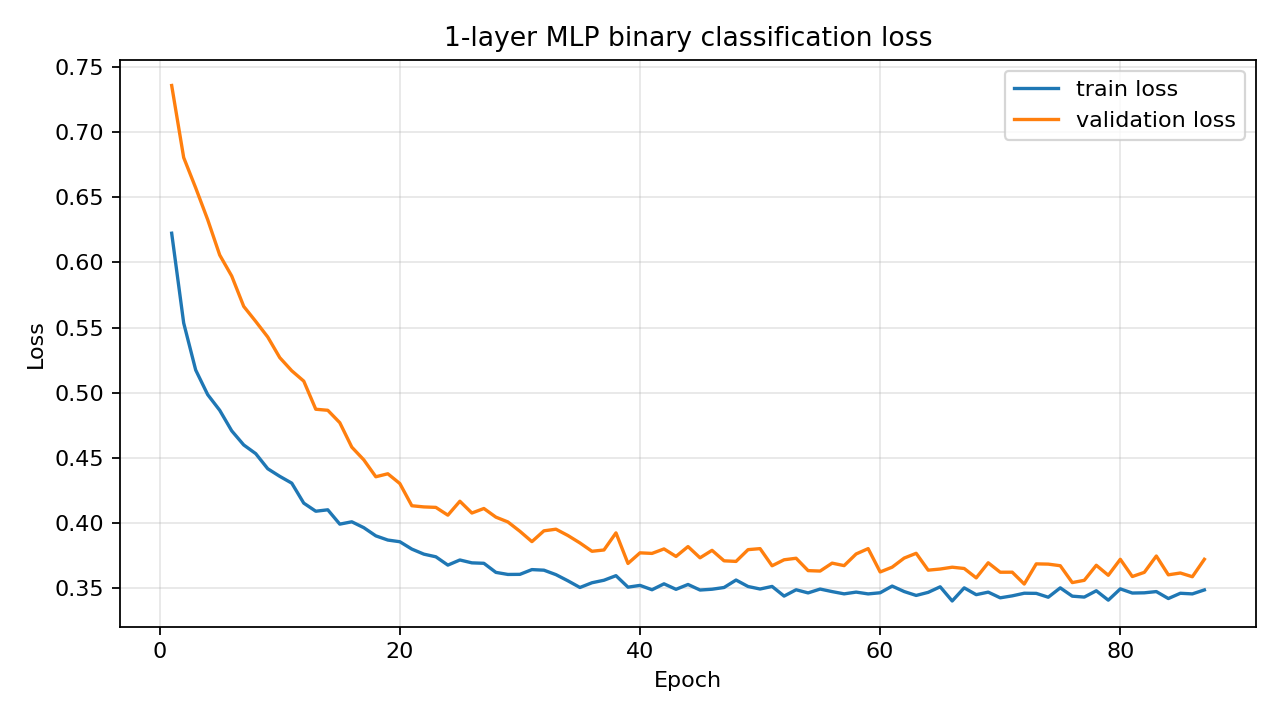

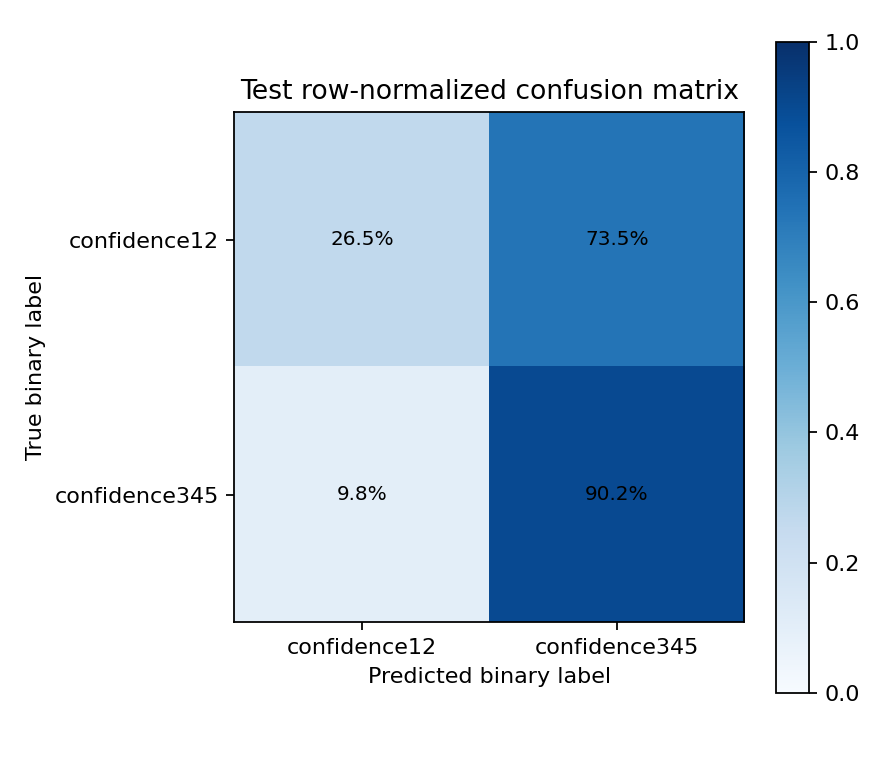

In [8]:
# =====================================================
# 8. RESULT FILES
# =====================================================
display(pd.read_csv(REPORT_DIR / "metrics_summary.csv"))
display(pd.read_csv(REPORT_DIR / "validation_classification_report.csv", index_col=0))
display(pd.read_csv(REPORT_DIR / "test_classification_report.csv", index_col=0))
display(Image(filename=str(PLOT_DIR / "train_val_loss.png")))
display(Image(filename=str(PLOT_DIR / "test_confusion_row_normalized.png")))
